In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

In [2]:
# read the csv with correct separator
# corect decimal, columns and missing values interpretation
data = pd.read_csv('E:/school/Masterat/Calcul Neuronal/LSTM_air_prediction/dataset/AirQuality.csv', sep=';', decimal=',', usecols=range(15), na_values=[-200])

# use the gpu if available
device = 'cuda:0' if torch.cuda.is_available() else 'cpu'

In [3]:
# handle the time columns
# add a new column timestamp whitch concatenates date and time columns and converts it to utc
data['Timestamp'] = (
    pd.to_datetime(data['Date'].astype(str) + ' ' + data['Time'].astype(str), format='%d/%m/%Y %H.%M.%S')
    .dt.tz_localize('UTC')
)
# drop old date and time columns
data = data.drop(columns=['Time'])
data = data.drop(columns=['Date'])
# set the index to timestamp column
data = data.set_index('Timestamp')

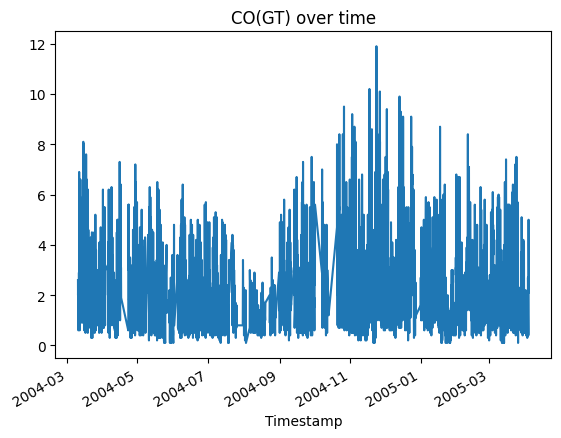

In [7]:
data['CO(GT)'].dropna().plot(title='CO(GT) over time')
plt.show()